# Objective

The goal of this project is to build an end-to-end machine learning pipeline using Tesla delivery and production data to predict Estimated_Deliveries and analyze delivery trends over time.

## Importing Libraries & Loading the Dataset


In [1]:
import pandas as pd
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


#Dataset Overview

In [2]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
Year                    0
Month                   0
Region                  0
Model                

# Exploratory Data Analysis (EDA)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


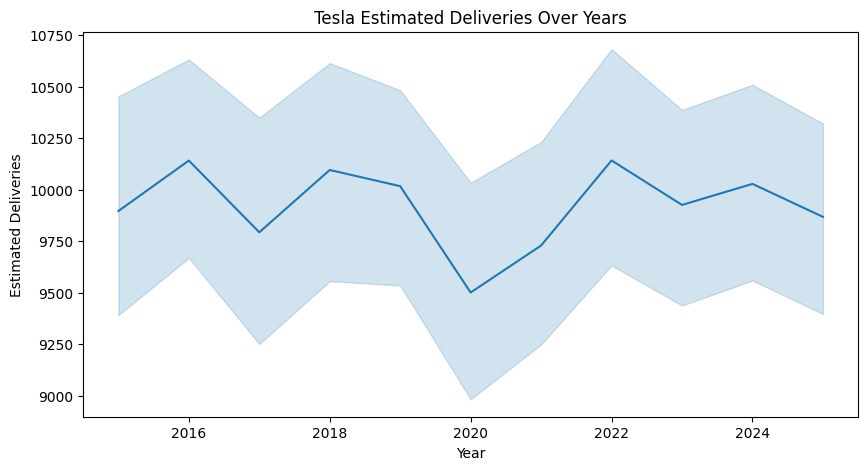

In [4]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)
plt.title('Tesla Estimated Deliveries Over Years')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.show()

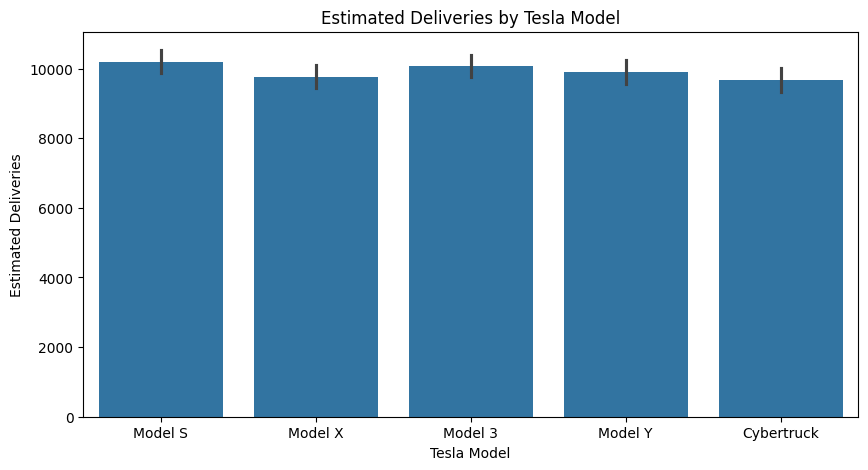

In [5]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df
)
plt.title('Estimated Deliveries by Tesla Model')
plt.xlabel('Tesla Model')
plt.ylabel('Estimated Deliveries')
plt.show()

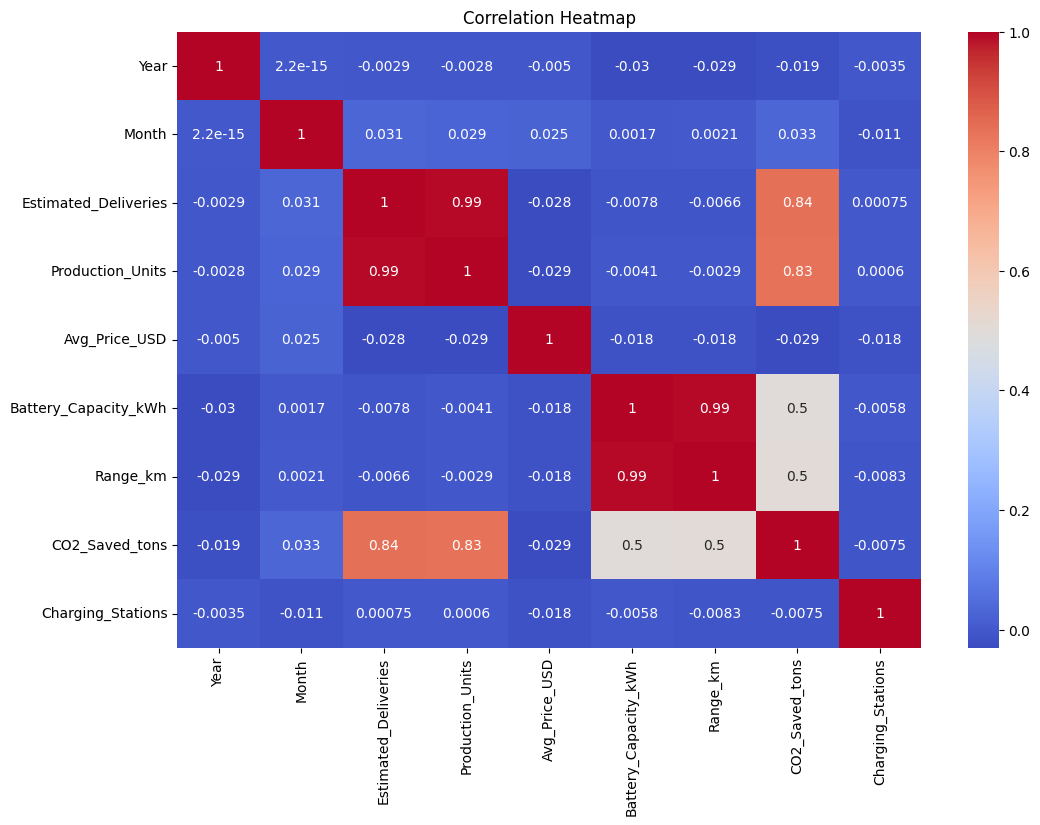

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

### Observation

Production units show the strongest relationship with estimated deliveries. Battery capacity and vehicle range are also highly related.

##Feature Encoding

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['Region', 'Model', 'Source_Type']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [8]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2640, 11)
Target Shape: (2640,)


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2112, 11)
X_test shape: (528, 11)
y_train shape: (2112,)
y_test shape: (528,)


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature scaling completed.")

Feature scaling completed.


In [11]:
from sklearn.linear_model import LinearRegression
# Create model
lr_model = LinearRegression()
# Train model
lr_model.fit(X_train, y_train)
# Predict on test data
y_pred = lr_model.predict(X_test)
print("Model training completed.")

Model training completed.


In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
# Print results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 310.1300215468204
MSE: 147130.98495353357
RMSE: 383.5765698703892
R2 Score: 0.9901296027802068


### Model Evaluation Observations

- The Linear Regression model achieved a very high R² score of approximately 0.99, indicating excellent predictive performance.
- Low MAE and RMSE values suggest that the prediction errors are relatively small.
- The model successfully captured the relationship between production, pricing, battery features, and estimated deliveries.

In [13]:
from sklearn.ensemble import RandomForestRegressor
# Create model
rf_model = RandomForestRegressor(
    random_state=42
)
# Train model
rf_model.fit(X_train, y_train)
# Predictions
rf_pred = rf_model.predict(X_test)
print("Random Forest training completed.")

Random Forest training completed.


In [14]:
# Random Forest Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 323.45475378787876
Random Forest MSE: 167632.1457433712
Random Forest RMSE: 409.42904848504725
Random Forest R2 Score: 0.988754266371452


### Random Forest Evaluation Observations

- Random Forest Regressor also achieved excellent predictive performance with a high R² score.
- However, Linear Regression slightly outperformed Random Forest on this dataset.
- This suggests that the dataset contains strong linear relationships between input features and estimated deliveries.

In [15]:
from sklearn.model_selection import GridSearchCV
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2'
)
grid.fit(X_train, y_train)
print("Best Parameters:")
print(grid.best_params_)
print("Best R2 Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}
Best R2 Score:
0.9880321073031793


### Hyperparameter Tuning Observations

- GridSearchCV was used for hyperparameter tuning of the Random Forest Regressor.
- Different combinations of n_estimators and max_depth were tested using cross-validation.
- The best-performing configuration used 100 estimators with a maximum depth of 10.
- The tuned model achieved a strong R² score, indicating robust predictive performance.

In [16]:
import matplotlib.pyplot as plt

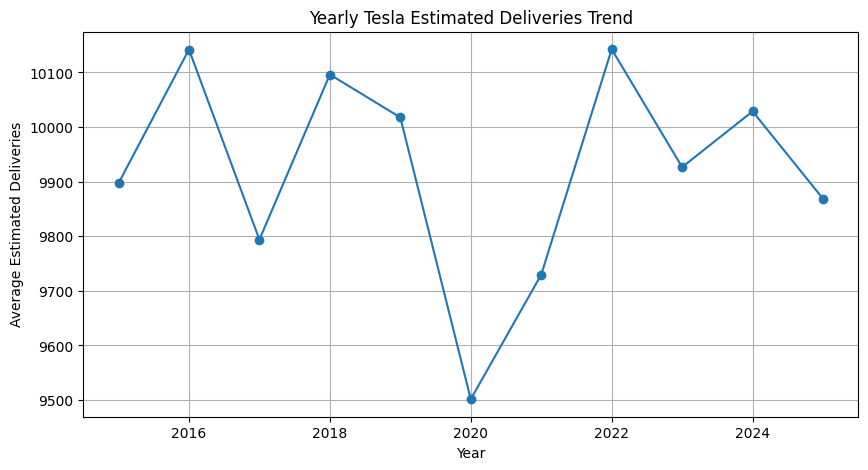

In [17]:
# Group yearly deliveries
yearly_deliveries = df.groupby('Year')[
    'Estimated_Deliveries'
].mean()
# Plot yearly trend
plt.figure(figsize=(10,5))
yearly_deliveries.plot(marker='o')
plt.title('Yearly Tesla Estimated Deliveries Trend')
plt.xlabel('Year')
plt.ylabel('Average Estimated Deliveries')
plt.grid(True)
plt.show()

### Forecasting / Trend Analysis Observations

- Tesla estimated deliveries show fluctuations over different years.
- A noticeable decline is observed around 2020, followed by recovery in subsequent years.
- Overall delivery performance remains relatively strong across the timeline.
- The trend analysis helps understand delivery patterns and supports future forecasting insights.

# Conclusion

This project implemented a complete end-to-end machine learning pipeline using Tesla deliveries and production data.

The workflow included:
- data loading and inspection
- exploratory data analysis (EDA)
- preprocessing and encoding
- feature scaling
- regression model training
- model evaluation
- hyperparameter tuning
- forecasting and trend analysis

Linear Regression and Random Forest Regression models were trained to predict Estimated_Deliveries using production, pricing, battery, and regional features.

The Linear Regression model achieved the best performance with a very high R² score, indicating strong predictive capability and strong relationships among dataset features.

Trend analysis also helped visualize yearly delivery fluctuations and overall delivery patterns across the timeline.